In [885]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [886]:
df=pd.read_csv('data_cleaned.csv')
dfinal=pd.read_csv('data.csv')

In [887]:
df.shape

(3716, 18)

In [888]:
df.describe()

,Order ID,Total Amount,Created At,Status,Rider Name,Rider Contact,Delivery Status,Expected ETA,Delay Reason,Scheduled Date,Scheduled Time,Packing Duration,Picked Up Duration,Out for Delivery Duration,Reached Delivery Duration,Reached Delivery Timestamp,Delivered Duration,Delivered Timestamp
count,3716,3716,3716,3716,3716,3716,3716,3716,3711,3716,3716,3716,3716,3716,3716,3716,3716,3716
unique,3716,1,3479,5,176,178,208,84,333,34,18,257,235,53,133,3328,172,3441
top,#18404,-,20 Jun 26 14:07,delivered,Rakesh EvRecharge,9695274568,On-Time,33 minutes,-,-,-,1m,2m,0m,-,-,0m,06 Jun 26 12:21
freq,1,3716,4,3708,142,85,2682,120,3013,3302,3302,973,711,1734,613,152,309,5


In [889]:
df.isnull().sum()

Order ID                      0
Total Amount                  0
Created At                    0
Status                        0
Rider Name                    0
Rider Contact                 0
Delivery Status               0
Expected ETA                  0
Delay Reason                  5
Scheduled Date                0
Scheduled Time                0
Packing Duration              0
Picked Up Duration            0
Out for Delivery Duration     0
Reached Delivery Duration     0
Reached Delivery Timestamp    0
Delivered Duration            0
Delivered Timestamp           0
dtype: int64

In [890]:
df.duplicated().sum()

np.int64(0)

In [891]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3716 entries, 0 to 3715
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Order ID                    3716 non-null   object
 1   Total Amount                3716 non-null   object
 2   Created At                  3716 non-null   object
 3   Status                      3716 non-null   object
 4   Rider Name                  3716 non-null   object
 5   Rider Contact               3716 non-null   object
 6   Delivery Status             3716 non-null   object
 7   Expected ETA                3716 non-null   object
 8   Delay Reason                3711 non-null   object
 9   Scheduled Date              3716 non-null   object
 10  Scheduled Time              3716 non-null   object
 11  Packing Duration            3716 non-null   object
 12  Picked Up Duration          3716 non-null   object
 13  Out for Delivery Duration   3716 non-null   obje

In [892]:
import datetime

In [893]:
from datetime import date,timedelta

In [894]:
df['Created At']=pd.to_datetime(df['Created At'])

/var/folders/md/bl7d8ffd71j23r2c46ylgpxm0000gn/T/ipykernel_6407/4093315771.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Created At']=pd.to_datetime(df['Created At'])


In [895]:
df['day']=df['Created At'].dt.day_name()

In [896]:
df['day']

0       Tuesday
1       Tuesday
2       Tuesday
3       Tuesday
4       Tuesday
         ...   
3711     Monday
3712     Monday
3713     Monday
3714     Monday
3715     Monday
Name: day, Length: 3716, dtype: object

In [897]:
df['d_type']=np.where(df['day'].isin(['Saturday','Sunday']),'Weekend','Weekday')

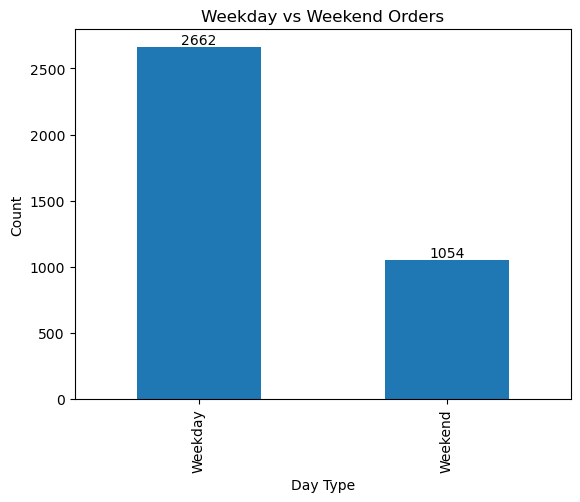

In [898]:
ax = df['d_type'].value_counts().plot(kind='bar')
ax.bar_label(ax.containers[0]) 
plt.title("Weekday vs Weekend Orders")
plt.xlabel("Day Type")
plt.ylabel("Count")
plt.show()


In [899]:
av_order_perday=df['Created At'].dt.date.value_counts().mean()
print(f"Average Orders Per day: {round(av_order_perday,2)} ")

Average Orders Per day: 123.87 


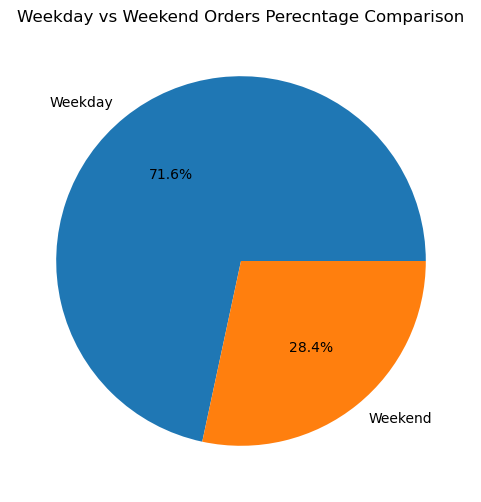

In [900]:
df['d_type'].value_counts().plot(kind='pie',autopct='%1.1f%%',ylabel='',figsize=(6,6),title='Weekday vs Weekend Orders Perecntage Comparison')
plt.show()

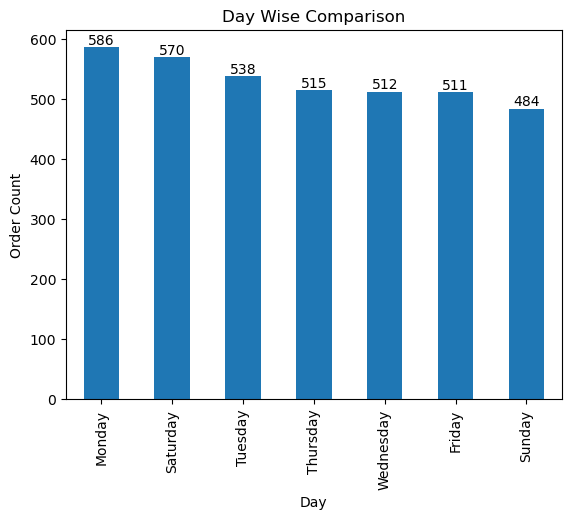

In [901]:
ax=df['day'].value_counts().plot(kind='bar')
ax.bar_label(ax.containers[0])
plt.xlabel('Day')
plt.ylabel('Order Count')
plt.title('Day Wise Comparison')
plt.show()

In [902]:
df['Hour']=df['Created At'].dt.hour

In [903]:
df['Hour']

0       23
1       23
2       23
3       23
4       23
        ..
3711     8
3712     7
3713     6
3714     6
3715     0
Name: Hour, Length: 3716, dtype: int32

In [904]:
df['Created At'] = pd.to_datetime(df['Created At'])
df['Date'] = df['Created At'].dt.date
df['Hour'] = df['Created At'].dt.hour

# Orders in each hour for each day
daily_hour = (
    df.groupby(['Date', 'Hour'])
      .size()
      .reset_index(name='Orders')
)

# Final table
result = (
    daily_hour.groupby('Hour')['Orders']
    .agg(
        Total_Orders='sum',
        Avg_Orders_per_Hour='mean'   
    )
    .reset_index()
)

result

,Hour,Total_Orders,Avg_Orders_per_Hour
0,0,81,2.793103
1,1,30,1.764706
2,2,10,1.250000
3,3,7,1.000000
4,4,8,1.142857
5,5,4,1.000000
6,6,18,1.384615
7,7,52,2.000000
8,8,98,3.629630
9,9,140,4.666667


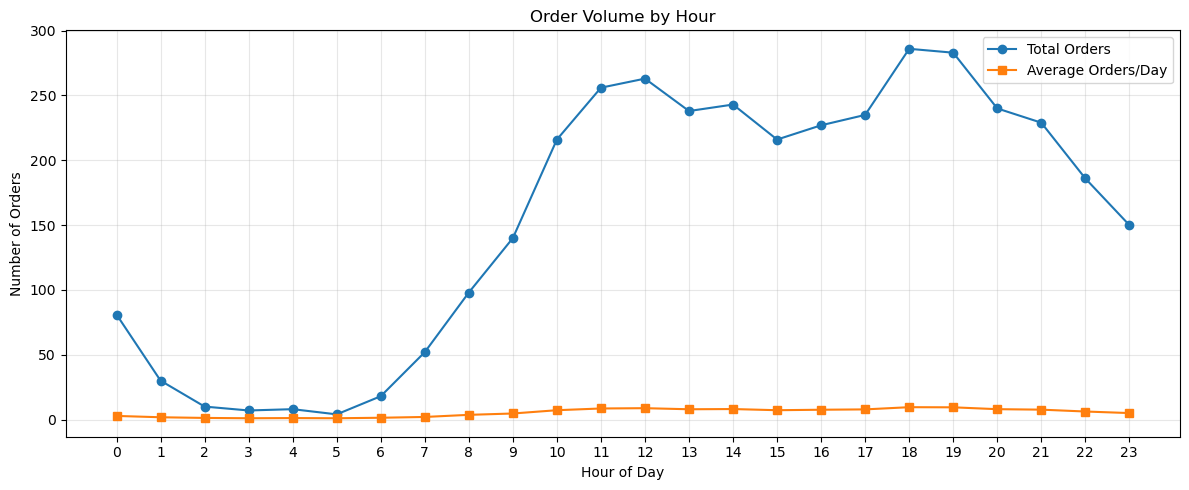

In [905]:
plt.figure(figsize=(12,5))

plt.plot(result['Hour'],
         result['Total_Orders'],
         marker='o',
         label='Total Orders')

plt.plot(result['Hour'],
         result['Avg_Orders_per_Hour'],
         marker='s',
         label='Average Orders/Day')

plt.xticks(range(24))
plt.xlabel('Hour of Day')
plt.ylabel('Number of Orders')
plt.title('Order Volume by Hour')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [906]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3716 entries, 0 to 3715
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Order ID                    3716 non-null   object        
 1   Total Amount                3716 non-null   object        
 2   Created At                  3716 non-null   datetime64[ns]
 3   Status                      3716 non-null   object        
 4   Rider Name                  3716 non-null   object        
 5   Rider Contact               3716 non-null   object        
 6   Delivery Status             3716 non-null   object        
 7   Expected ETA                3716 non-null   object        
 8   Delay Reason                3711 non-null   object        
 9   Scheduled Date              3716 non-null   object        
 10  Scheduled Time              3716 non-null   object        
 11  Packing Duration            3716 non-null   object      

In [907]:
df['Delivered Timestamp']=pd.to_datetime(df['Delivered Timestamp'])

/var/folders/md/bl7d8ffd71j23r2c46ylgpxm0000gn/T/ipykernel_6407/501969382.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Delivered Timestamp']=pd.to_datetime(df['Delivered Timestamp'])


In [908]:
df['del_time']=df['Delivered Timestamp']-df['Created At']
df['del_time']=df['del_time'].dt.total_seconds()/60
df['del_time']

0        65.0
1       708.0
2       503.0
3       610.0
4        69.0
        ...  
3711     32.0
3712     29.0
3713    102.0
3714     57.0
3715     59.0
Name: del_time, Length: 3716, dtype: float64

In [909]:
df['Delivered Duration'] = pd.to_timedelta(df['Delivered Duration'], errors='coerce')

# Convert to minutes
df['delduration_min'] = (
    df['Delivered Duration']
      .dt.total_seconds() / 60
)

In [910]:
df['delduration_min']

0        0.0
1        0.0
2        5.0
3        9.0
4       34.0
        ... 
3711    24.0
3712    15.0
3713     8.0
3714     6.0
3715     1.0
Name: delduration_min, Length: 3716, dtype: float64

In [911]:
avg_del_duration=df['delduration_min'].dropna().mean()

In [912]:
print(f"Average Delivery Duration (Minutes): {round(avg_del_duration,2)} ")

Average Delivery Duration (Minutes): 41.81 


In [913]:
no_of_orders_perhr=60/avg_del_duration
print(f"No of Orders Per Hour: {round(no_of_orders_perhr,2)}")

No of Orders Per Hour: 1.44


In [914]:
result['Rides Required'] = np.ceil(1.20*result['Avg_Orders_per_Hour'] / no_of_orders_perhr)
# Assuming Buffer of 20%

In [915]:
result

,Hour,Total_Orders,Avg_Orders_per_Hour,Rides Required
0,0,81,2.793103,3.0
1,1,30,1.764706,2.0
2,2,10,1.250000,2.0
3,3,7,1.000000,1.0
4,4,8,1.142857,1.0
5,5,4,1.000000,1.0
6,6,18,1.384615,2.0
7,7,52,2.000000,2.0
8,8,98,3.629630,4.0
9,9,140,4.666667,4.0


In [916]:
result['Shift'] = pd.cut(
    result['Hour'],
    bins=[-1, 7, 15, 23],
    labels=['Shift 1', 'Shift 2', 'Shift 3']
)

result

,Hour,Total_Orders,Avg_Orders_per_Hour,Rides Required,Shift
0,0,81,2.793103,3.0,Shift 1
1,1,30,1.764706,2.0,Shift 1
2,2,10,1.250000,2.0,Shift 1
3,3,7,1.000000,1.0,Shift 1
4,4,8,1.142857,1.0,Shift 1
5,5,4,1.000000,1.0,Shift 1
6,6,18,1.384615,2.0,Shift 1
7,7,52,2.000000,2.0,Shift 1
8,8,98,3.629630,4.0,Shift 2
9,9,140,4.666667,4.0,Shift 2


In [917]:
result.groupby('Shift', observed=True).agg(Peak_Orders=('Avg_Orders_per_Hour', 'max'),Riders_Required=('Rides Required', 'max')).reset_index()


,Shift,Peak_Orders,Riders_Required
0,Shift 1,2.793103,3.0
1,Shift 2,8.766667,8.0
2,Shift 3,9.533333,8.0


In [918]:
df['Expected_ETA']=df['Expected ETA'].str.split().str[0].astype(float)
df['Expected_ETA']

0       60.0
1       60.0
2       49.0
3       53.0
4       60.0
        ... 
3711    34.0
3712    28.0
3713    49.0
3714    45.0
3715    51.0
Name: Expected_ETA, Length: 3716, dtype: float64

In [919]:
df['within_eta']=np.where(df['Expected_ETA']>df['delduration_min'],'True','False')

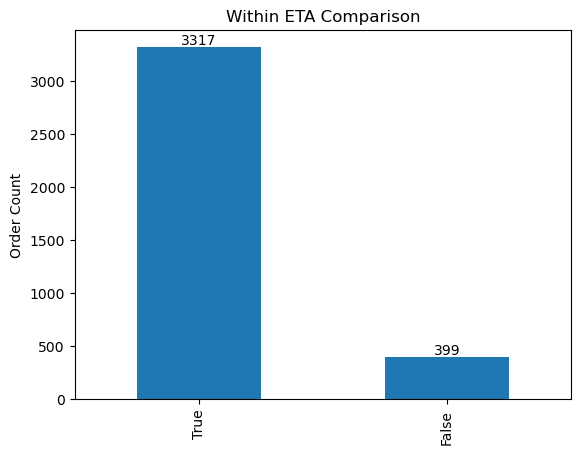

In [920]:
ax=df['within_eta'].value_counts().plot(kind='bar')
ax.bar_label(ax.containers[0])
plt.xlabel('')
plt.ylabel('Order Count')
plt.title('Within ETA Comparison')
plt.show()

<Axes: xlabel='Status'>

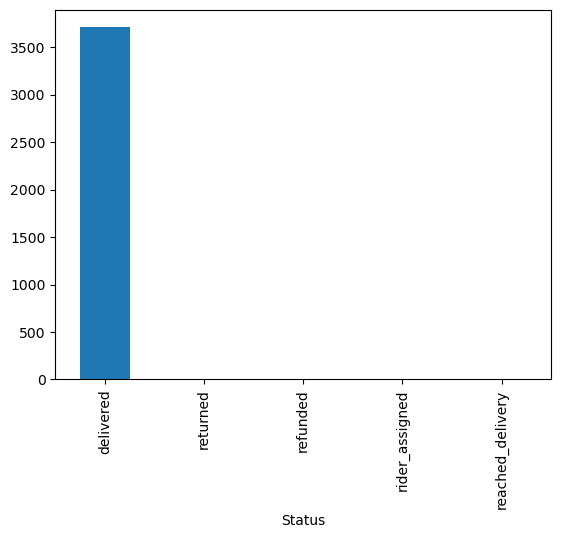

In [921]:
df['Status'].value_counts().plot(kind='bar')

In [922]:
df['late_del']=np.where(df['Expected_ETA']<df['delduration_min'],'True','False')

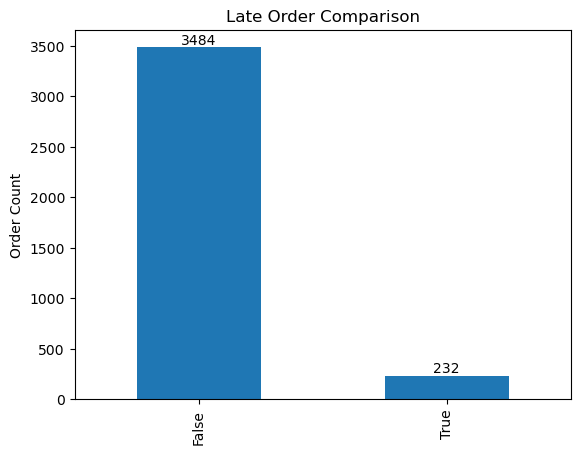

In [923]:
ax=df['late_del'].value_counts().plot(kind='bar')
ax.bar_label(ax.containers[0])
plt.xlabel('')
plt.ylabel('Order Count')
plt.title('Late Order Comparison')
plt.show()

In [924]:
df['delay']=np.where(df['delduration_min']-df['Expected_ETA']>0,df['delduration_min']-df['Expected_ETA'],0)

In [925]:
avg_del=df['delay'].mean()

In [926]:
print(f"Average Delay (Minutes): {round(avg_del,2)} ")

Average Delay (Minutes): 27.37 


In [927]:
dfinal.drop(dfinal[dfinal['Order ID'] == 'Order ID'].index, inplace=True)

In [928]:
dfinal.pivot_table(columns=['Status'],values=['Order ID'],aggfunc='count')

Status,cancelled,delivered,exchanged,out_for_delivery,packed,packing,placed,reached_delivery,refunded,returned,rider_assigned
Order ID,786,7424,2,92,70,102,2,164,26,8,40


In [939]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3716 entries, 0 to 3715
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype          
---  ------                      --------------  -----          
 0   Order ID                    3716 non-null   object         
 1   Total Amount                3716 non-null   object         
 2   Created At                  3716 non-null   datetime64[ns] 
 3   Status                      3716 non-null   object         
 4   Rider Name                  3716 non-null   object         
 5   Rider Contact               3716 non-null   object         
 6   Delivery Status             3716 non-null   object         
 7   Expected ETA                3716 non-null   object         
 8   Delay Reason                3711 non-null   object         
 9   Scheduled Date              3716 non-null   object         
 10  Scheduled Time              3716 non-null   object         
 11  Packing Duration            3716 non-null  

In [935]:
avg_delay = df['delduration_min'].mean()

print(f"Average time from Out for Delivery to Delivered: {avg_delay:.2f} minutes")

Average time from Out for Delivery to Delivered: 41.81 minutes


In [936]:
df.to_csv('df_end.csv')

In [946]:
df[['Order ID','Delivered Duration','delduration_min','Delay Reason']].sort_values('delduration_min', ascending=False).head(25)




,Order ID,Delivered Duration,delduration_min,Delay Reason
3582,#14044,15 days 21:24:00,22884.0,bigger size not avaliable
1509,#16568,7 days 22:13:00,11413.0,Item NA at store
1068,#17116,6 days 08:57:00,9177.0,size
2442,#15388,2 days 23:14:00,4274.0,size
988,#17217,2 days 08:26:00,3386.0,Marked as delivered manually
1518,#16559,2 days 03:38:00,3098.0,Marked as delivered manually
3068,#14675,1 days 23:13:00,2833.0,scratches on the bottle
3382,#14293,1 days 20:48:00,2688.0,size and quality issue
930,#17287,1 days 20:15:00,2655.0,Marked as delivered manually
3394,#14281,1 days 19:56:00,2636.0,"size issue , cx placed a new order"


In [947]:
print(df['delduration_min'].describe())

count     3564.000000
mean        41.806117
std        485.768710
min          0.000000
25%          4.000000
50%          8.000000
75%         16.000000
max      22884.000000
Name: delduration_min, dtype: float64


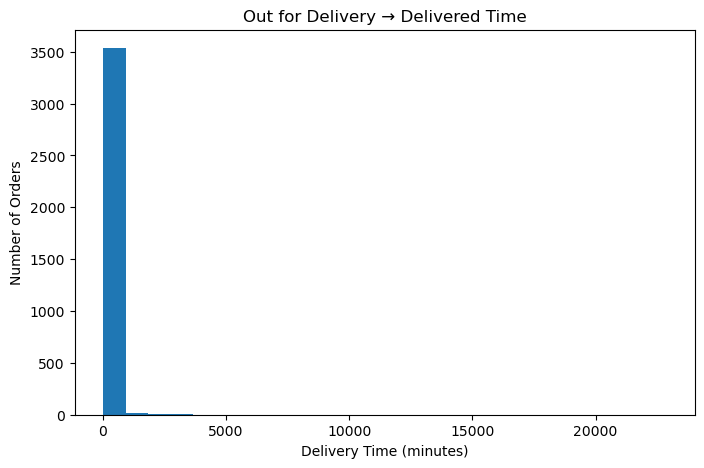

In [949]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['delduration_min'], bins=25)
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Number of Orders")
plt.title("Out for Delivery → Delivered Time")
plt.show()

In [952]:
avg_eta=df['Expected_ETA'].mean()

In [953]:
print(f"Average ETA: {avg_eta:.2f} minutes")

Average ETA: 50.69 minutes


In [956]:
df['delduration_min'].mean()

pd.DataFrame({
    'Metric': ['Average ETA', 'Average Actual Delivery'],
    'Minutes': [round(avg_eta,2), round(avg_actual,2)]
})



,Metric,Minutes
0,Average ETA,50.69
1,Average Actual Delivery,41.81


In [957]:
df['ETA_Variance'] = df['delduration_min'] - df['Expected_ETA']

avg_variance = df['ETA_Variance'].mean()

print(f"Average ETA Variance: {avg_variance:.2f} minutes")

Average ETA Variance: -8.96 minutes


In [958]:
accuracy = (
    (df['ETA_Variance'].abs() <= 5)
    .mean()
    * 100
)

print(f"ETA Prediction Accuracy: {accuracy:.2f}%")

ETA Prediction Accuracy: 3.96%
